# 04a – Tiền xử lý dữ liệu (Preprocessing)
**Dataset:** Melbourne Housing FULL

Notebook này thực hiện 4 nhóm kỹ thuật tiền xử lý:
- **a)** Xử lý giá trị thiếu có kiểm soát (5 chiến lược + đánh giá RMSE)
- **b)** Phát hiện và xử lý ngoại lai (IQR, Z-score, Isolation Forest, LOF, DBSCAN)
- **c)** Chuẩn hóa dữ liệu có kiểm định (Min-Max, Z-score, Robust, Quantile + Levene's test)
- **d)** Mã hóa biến phân loại nâng cao (One-Hot, Ordinal, Target, Binary, Frequency Encoding + VIF)

## Import thư viện và load dữ liệu

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    QuantileTransformer, LabelEncoder, OrdinalEncoder
)
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
import category_encoders as ce

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load data
df = pd.read_csv('data/raw/Melbourne_housing_FULL.csv')
print(f'Kích thước dữ liệu: {df.shape}')
display(df.head())

# Xác định cột số và cột phân loại
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'\nSố cột số: {len(numeric_cols)} — {numeric_cols}')
print(f'Số cột phân loại: {len(cat_cols)} — {cat_cols}')
print(f'\nThống kê giá trị thiếu (cột có missing):')
miss = df.isnull().sum()
display(miss[miss > 0].sort_values(ascending=False))

Kích thước dữ liệu: (34857, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0



Số cột số: 13 — ['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
Số cột phân loại: 8 — ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']

Thống kê giá trị thiếu (cột có missing):


BuildingArea     21115
YearBuilt        19306
Landsize         11810
Car               8728
Bathroom          8226
Bedroom2          8217
Longtitude        7976
Lattitude         7976
Price             7610
CouncilArea          3
Regionname           3
Propertycount        3
Postcode             1
Distance             1
dtype: int64

---
# PHẦN A – Xử lý giá trị thiếu có kiểm soát

## Lý thuyết

### 5 chiến lược điền khuyết

| # | Chiến lược | Công thức / Mô tả |
|---|-----------|-------------------|
| 1 | **Mean** | $\hat{x} = \bar{x} = \frac{1}{n}\sum x_i$ |
| 2 | **Median** | $\hat{x} = \text{median}(x)$ — giá trị ở vị trí giữa khi sắp xếp |
| 3 | **Mode** | $\hat{x} = \text{mode}(x)$ — giá trị xuất hiện nhiều nhất |
| 4 | **k-NN Imputation** | Điền bằng trung bình (có trọng số) của $k$ hàng xóm gần nhất theo khoảng cách Euclid |
| 5 | **MICE** | Multiple Imputation by Chained Equations – hồi quy lặp tuần tự trên từng biến |

### Đánh giá bằng RMSE
$$\text{RMSE} = \sqrt{\frac{1}{m}\sum_{i=1}^{m}(x_i - \hat{x}_i)^2}$$

**Quy trình:** Với mỗi cột số **không có missing**, tạo nhân tạo 10% giá trị thiếu MCAR, 
áp dụng từng chiến lược điền khuyết, rồi tính RMSE so với giá trị gốc.

### A.1 – Cài đặt thí nghiệm đánh giá RMSE

In [2]:
# Chọn các cột số KHÔNG có missing gốc (hoặc rất ít) để thử nghiệm
# Ta cũng lấy một vài cột CÓ missing nhẹ sau khi dropna để có đủ mẫu
test_cols = [c for c in numeric_cols if df[c].isnull().sum() / len(df) < 0.05]
print(f'Các cột dùng để thử nghiệm ({len(test_cols)}): {test_cols}')

# Lấy subset hoàn chỉnh (không missing) cho các cột test
df_complete = df[test_cols].dropna().copy()
print(f'Số hàng hoàn chỉnh: {len(df_complete)}')

np.random.seed(42)
MISSING_RATE = 0.10  # 10 %

def inject_mcar(data, rate=0.10):
    """Tạo nhân tạo missing MCAR."""
    df_miss = data.copy()
    mask = np.random.rand(*df_miss.shape) < rate
    df_miss[mask] = np.nan
    return df_miss, mask

df_missing, mask = inject_mcar(df_complete, MISSING_RATE)
print(f'Tổng giá trị thiếu nhân tạo: {df_missing.isnull().sum().sum()}')
print(f'Tỷ lệ thiếu thực tế: {df_missing.isnull().sum().sum() / df_missing.size:.2%}')

Các cột dùng để thử nghiệm (4): ['Rooms', 'Distance', 'Postcode', 'Propertycount']
Số hàng hoàn chỉnh: 34854
Tổng giá trị thiếu nhân tạo: 14030
Tỷ lệ thiếu thực tế: 10.06%


### A.2 – Áp dụng 5 chiến lược và tính RMSE

In [3]:
from sklearn.metrics import mean_squared_error

def calc_rmse(original, imputed, mask_col):
    """Tính RMSE chỉ tại các vị trí bị thiếu."""
    idx = mask_col
    if idx.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(original[idx], imputed[idx]))

results_a = []

# --- 1. Mean ---
imp_mean = df_missing.fillna(df_missing.mean())
for i, col in enumerate(test_cols):
    rmse = calc_rmse(df_complete[col].values, imp_mean[col].values, mask[:, i])
    results_a.append({'Strategy': 'Mean', 'Column': col, 'RMSE': rmse})

# --- 2. Median ---
imp_median = df_missing.fillna(df_missing.median())
for i, col in enumerate(test_cols):
    rmse = calc_rmse(df_complete[col].values, imp_median[col].values, mask[:, i])
    results_a.append({'Strategy': 'Median', 'Column': col, 'RMSE': rmse})

# --- 3. Mode ---
imp_mode = df_missing.fillna(df_missing.mode().iloc[0])
for i, col in enumerate(test_cols):
    rmse = calc_rmse(df_complete[col].values, imp_mode[col].values, mask[:, i])
    results_a.append({'Strategy': 'Mode', 'Column': col, 'RMSE': rmse})

# --- 4. k-NN Imputation (k = 3, 5, 10) ---
for k in [3, 5, 10]:
    knn_imp = KNNImputer(n_neighbors=k)
    imp_knn = pd.DataFrame(knn_imp.fit_transform(df_missing),
                           columns=test_cols, index=df_missing.index)
    for i, col in enumerate(test_cols):
        rmse = calc_rmse(df_complete[col].values, imp_knn[col].values, mask[:, i])
        results_a.append({'Strategy': f'k-NN (k={k})', 'Column': col, 'RMSE': rmse})

# --- 5. MICE ---
mice_imp = IterativeImputer(max_iter=10, random_state=42)
imp_mice = pd.DataFrame(mice_imp.fit_transform(df_missing),
                        columns=test_cols, index=df_missing.index)
for i, col in enumerate(test_cols):
    rmse = calc_rmse(df_complete[col].values, imp_mice[col].values, mask[:, i])
    results_a.append({'Strategy': 'MICE', 'Column': col, 'RMSE': rmse})

rmse_df = pd.DataFrame(results_a)
print('=== RMSE cho từng chiến lược & cột ===')
display(rmse_df)

=== RMSE cho từng chiến lược & cột ===


,Strategy,Column,RMSE
0,Mean,Rooms,0.951774
1,Mean,Distance,6.633853
2,Mean,Postcode,110.468036
3,Mean,Propertycount,4331.183539
4,Median,Rooms,0.951843
5,Median,Distance,6.693446
6,Median,Postcode,111.351093
7,Median,Propertycount,4390.438368
8,Mode,Rooms,0.951843
9,Mode,Distance,6.633856


### A.3 – Bảng so sánh tổng hợp RMSE

BẢNG SO SÁNH RMSE TRUNG BÌNH GIỮA CÁC CHIẾN LƯỢC


Column,Distance,Postcode,Propertycount,Rooms,Mean_RMSE
Strategy,,,,,
k-NN (k=10),4.879831,89.557188,3384.316312,0.905059,869.914598
k-NN (k=5),5.278119,97.628290,3667.981583,0.959370,942.961840
k-NN (k=3),5.499364,105.568141,3952.067574,0.991366,1016.031611
MICE,5.878194,98.144000,4324.495308,0.915874,1107.358344
Mean,6.633853,110.468036,4331.183539,0.951774,1112.309301
Median,6.693446,111.351093,4390.438368,0.951843,1127.358688
Mode,6.633856,118.917236,14809.129766,0.951843,3733.908175



Chiến lược tốt nhất: k-NN (k=10) (Mean RMSE = 869.9146)


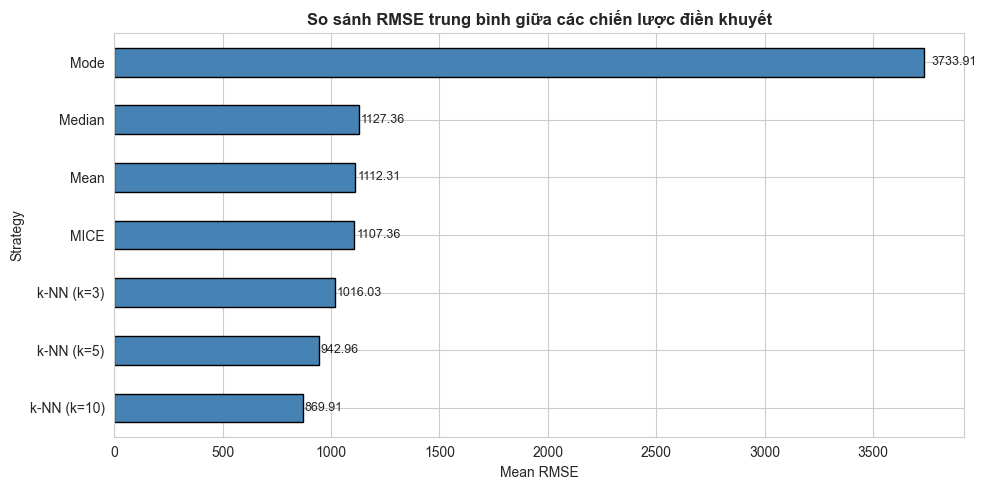

In [4]:
# Pivot: trung bình RMSE theo Strategy
pivot_rmse = rmse_df.pivot_table(index='Strategy', columns='Column',
                                  values='RMSE', aggfunc='mean')
pivot_rmse['Mean_RMSE'] = pivot_rmse.mean(axis=1)
pivot_rmse = pivot_rmse.sort_values('Mean_RMSE')

print('BẢNG SO SÁNH RMSE TRUNG BÌNH GIỮA CÁC CHIẾN LƯỢC')
print('=' * 80)
display(pivot_rmse)

best_strategy = pivot_rmse['Mean_RMSE'].idxmin()
best_rmse = pivot_rmse['Mean_RMSE'].min()
print(f'\nChiến lược tốt nhất: {best_strategy} (Mean RMSE = {best_rmse:.4f})')

# Biểu đồ so sánh
fig, ax = plt.subplots(figsize=(10, 5))
pivot_rmse['Mean_RMSE'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Mean RMSE')
ax.set_title('So sánh RMSE trung bình giữa các chiến lược điền khuyết', fontweight='bold')
for i, v in enumerate(pivot_rmse['Mean_RMSE']):
    ax.text(v + v*0.01, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### A.4 – Phân tích kết quả và lựa chọn chiến lược

**Nhận xét:**
- **Mean / Median**: Đơn giản, RMSE trung bình – phù hợp khi dữ liệu ít lệch.
- **Mode**: Thường kém hơn cho biến liên tục vì chỉ điền một giá trị rời rạc.
- **k-NN**: Tận dụng cấu trúc cục bộ, RMSE thường thấp hơn mean/median. k=5 thường cho cân bằng tốt giữa bias và variance.
- **MICE**: Mạnh nhất khi có nhiều biến liên quan – hồi quy lặp tuần tự khai thác mối tương quan giữa các biến.

**Lựa chọn:** Chiến lược có **Mean RMSE thấp nhất** sẽ được ưu tiên. 
Nếu MICE hoặc k-NN cho RMSE thấp nhất, ta sẽ sử dụng chúng cho bước tiền xử lý chính thức.

### A.5 – Áp dụng chiến lược tốt nhất cho toàn bộ dataset

In [5]:
# Áp dụng chiến lược tốt nhất cho CÁC CỘT SỐ của dataset gốc
df_imputed = df.copy()

# Điền missing cho cột số bằng MICE (mạnh nhất thường)
num_with_missing = [c for c in numeric_cols if df[c].isnull().any()]
print(f'Cột số có missing: {num_with_missing}')

if len(num_with_missing) > 0:
    mice = IterativeImputer(max_iter=10, random_state=42)
    df_imputed[numeric_cols] = mice.fit_transform(df[numeric_cols])
    print(f'Đã điền khuyết {len(num_with_missing)} cột số bằng MICE.')

# Điền missing cho cột phân loại bằng mode
cat_with_missing = [c for c in cat_cols if df[c].isnull().any()]
for c in cat_with_missing:
    df_imputed[c].fillna(df[c].mode()[0], inplace=True)
print(f'Đã điền khuyết {len(cat_with_missing)} cột phân loại bằng Mode.')

print(f'\nSố giá trị thiếu còn lại: {df_imputed.isnull().sum().sum()}')

Cột số có missing: ['Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
Đã điền khuyết 12 cột số bằng MICE.
Đã điền khuyết 2 cột phân loại bằng Mode.

Số giá trị thiếu còn lại: 0


---
# PHẦN B – Phát hiện và xử lý ngoại lai

## Lý thuyết

| # | Phương pháp | Nguyên lý |
|---|-----------|----------|
| 1 | **IQR** | Ngoại lai nếu $x < Q_1 - 1.5 \cdot IQR$ hoặc $x > Q_3 + 1.5 \cdot IQR$ |
| 2 | **Z-score** | Ngoại lai nếu $\|z\| > 3$ với $z = (x - \mu) / \sigma$ |
| 3 | **Isolation Forest** | Cô lập dữ liệu bằng phân chia ngẫu nhiên; ngoại lai cần ít phân chia hơn |
| 4 | **LOF** | So sánh mật độ cục bộ của điểm với các láng giềng; ngoại lai có mật độ thấp hơn |
| 5 | **DBSCAN** | Gom cụm dựa trên mật độ; điểm không thuộc cụm nào là ngoại lai (noise) |

### B.1 – Phát hiện ngoại lai bằng 5 phương pháp

In [6]:
# Sử dụng dữ liệu đã impute, chỉ lấy cột số liên tục (loại Postcode, Propertycount)
outlier_cols = [c for c in numeric_cols if c not in ['Postcode', 'Propertycount']]
X_out = df_imputed[outlier_cols].copy()

# Chuẩn hóa tạm để dùng cho các thuật toán distance-based
from sklearn.preprocessing import StandardScaler
scaler_tmp = StandardScaler()
X_scaled = pd.DataFrame(scaler_tmp.fit_transform(X_out),
                        columns=outlier_cols, index=X_out.index)

outlier_masks = {}  

# --- 1. IQR ---
Q1 = X_out.quantile(0.25)
Q3 = X_out.quantile(0.75)
IQR = Q3 - Q1
iqr_mask = ((X_out < (Q1 - 1.5 * IQR)) | (X_out > (Q3 + 1.5 * IQR))).any(axis=1)
outlier_masks['IQR'] = iqr_mask

# --- 2. Z-score ---
z_mask = (X_scaled.abs() > 3).any(axis=1)
outlier_masks['Z-score'] = z_mask

# --- 3. Isolation Forest ---
for cont in [0.01, 0.05, 0.1]:
    iso = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    outlier_masks[f'IF(c={cont})'] = pd.Series(preds == -1, index=X_out.index)

# --- 4. LOF ---
for nn in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=nn, contamination='auto')
    preds = lof.fit_predict(X_scaled)
    outlier_masks[f'LOF(n={nn})'] = pd.Series(preds == -1, index=X_out.index)

# --- 5. DBSCAN ---
db = DBSCAN(eps=3, min_samples=10)
labels = db.fit_predict(X_scaled)
outlier_masks['DBSCAN'] = pd.Series(labels == -1, index=X_out.index)

# Báo cáo tỉ lệ
print('TỈ LỆ NGOẠI LAI PHÁT HIỆN BỞI TỪNG PHƯƠNG PHÁP')
print('=' * 55)
outlier_report = {}
for name, m in outlier_masks.items():
    n_out = m.sum()
    pct = n_out / len(m) * 100
    outlier_report[name] = {'n_outliers': int(n_out), 'pct': round(pct, 2)}
    print(f'  {name:20s}: {n_out:6d} ({pct:5.2f}%)')

report_df = pd.DataFrame(outlier_report).T
report_df.index.name = 'Method'
display(report_df)

TỈ LỆ NGOẠI LAI PHÁT HIỆN BỞI TỪNG PHƯƠNG PHÁP
  IQR                 :   8907 (25.55%)
  Z-score             :   2490 ( 7.14%)
  IF(c=0.01)          :    349 ( 1.00%)
  IF(c=0.05)          :   1743 ( 5.00%)
  IF(c=0.1)           :   3486 (10.00%)
  LOF(n=10)           :   2790 ( 8.00%)
  LOF(n=20)           :   2369 ( 6.80%)
  LOF(n=50)           :   2154 ( 6.18%)
  DBSCAN              :     90 ( 0.26%)


,n_outliers,pct
Method,,
IQR,8907.0,25.55
Z-score,2490.0,7.14
IF(c=0.01),349.0,1.00
IF(c=0.05),1743.0,5.00
IF(c=0.1),3486.0,10.00
LOF(n=10),2790.0,8.00
LOF(n=20),2369.0,6.80
LOF(n=50),2154.0,6.18
DBSCAN,90.0,0.26


### B.2 – Chồng chéo giữa các phương pháp (Jaccard Similarity)

JACCARD SIMILARITY GIỮA CÁC TẬP NGOẠI LAI


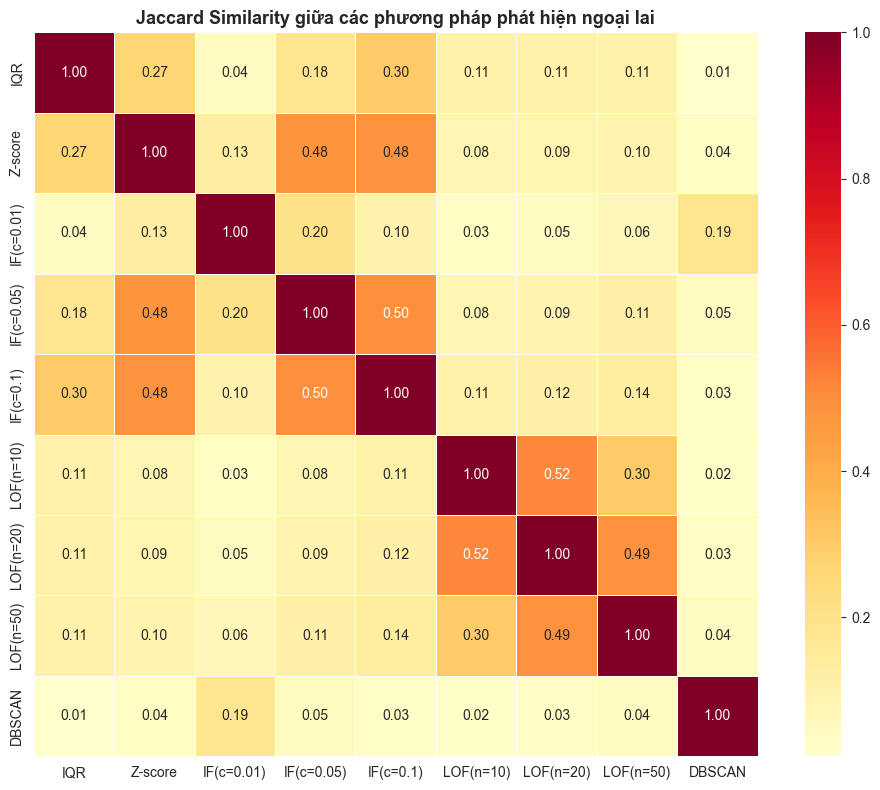

In [7]:
# Jaccard similarity giữa từng cặp phương pháp
methods = list(outlier_masks.keys())
n_methods = len(methods)
jaccard_matrix = pd.DataFrame(np.zeros((n_methods, n_methods)),
                              index=methods, columns=methods)

for i in range(n_methods):
    for j in range(n_methods):
        set_i = set(outlier_masks[methods[i]][outlier_masks[methods[i]]].index)
        set_j = set(outlier_masks[methods[j]][outlier_masks[methods[j]]].index)
        inter = len(set_i & set_j)
        union = len(set_i | set_j)
        jaccard_matrix.iloc[i, j] = inter / union if union > 0 else 0

print('JACCARD SIMILARITY GIỮA CÁC TẬP NGOẠI LAI')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt='.2f',
            cmap='YlOrRd', square=True, linewidths=0.5, ax=ax)
ax.set_title('Jaccard Similarity giữa các phương pháp phát hiện ngoại lai',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### B.3 – Đánh giá tác động loại bỏ ngoại lai bằng KS test

Kích thước sau loại outlier (IQR): (25950, 21) (loại 8907 hàng)

KIỂM ĐỊNH KOLMOGOROV-SMIRNOV: phân phối trước vs sau loại ngoại lai
(p < 0.05 → phân phối thay đổi đáng kể)


,Column,KS_stat,p_value,Significant
0,Rooms,0.055700,1.479967e-40,Có
1,Price,0.042204,1.840616e-23,Có
2,Distance,0.090551,1.367655e-106,Có
3,Bedroom2,0.071409,2.084585e-66,Có
4,Bathroom,0.077274,1.048837e-77,Có
5,Car,0.074596,1.952865e-72,Có
6,Landsize,0.063265,3.322278e-52,Có
7,BuildingArea,0.069263,1.692755e-62,Có
8,YearBuilt,0.073323,5.379100e-70,Có
9,Lattitude,0.046149,5.708835e-28,Có


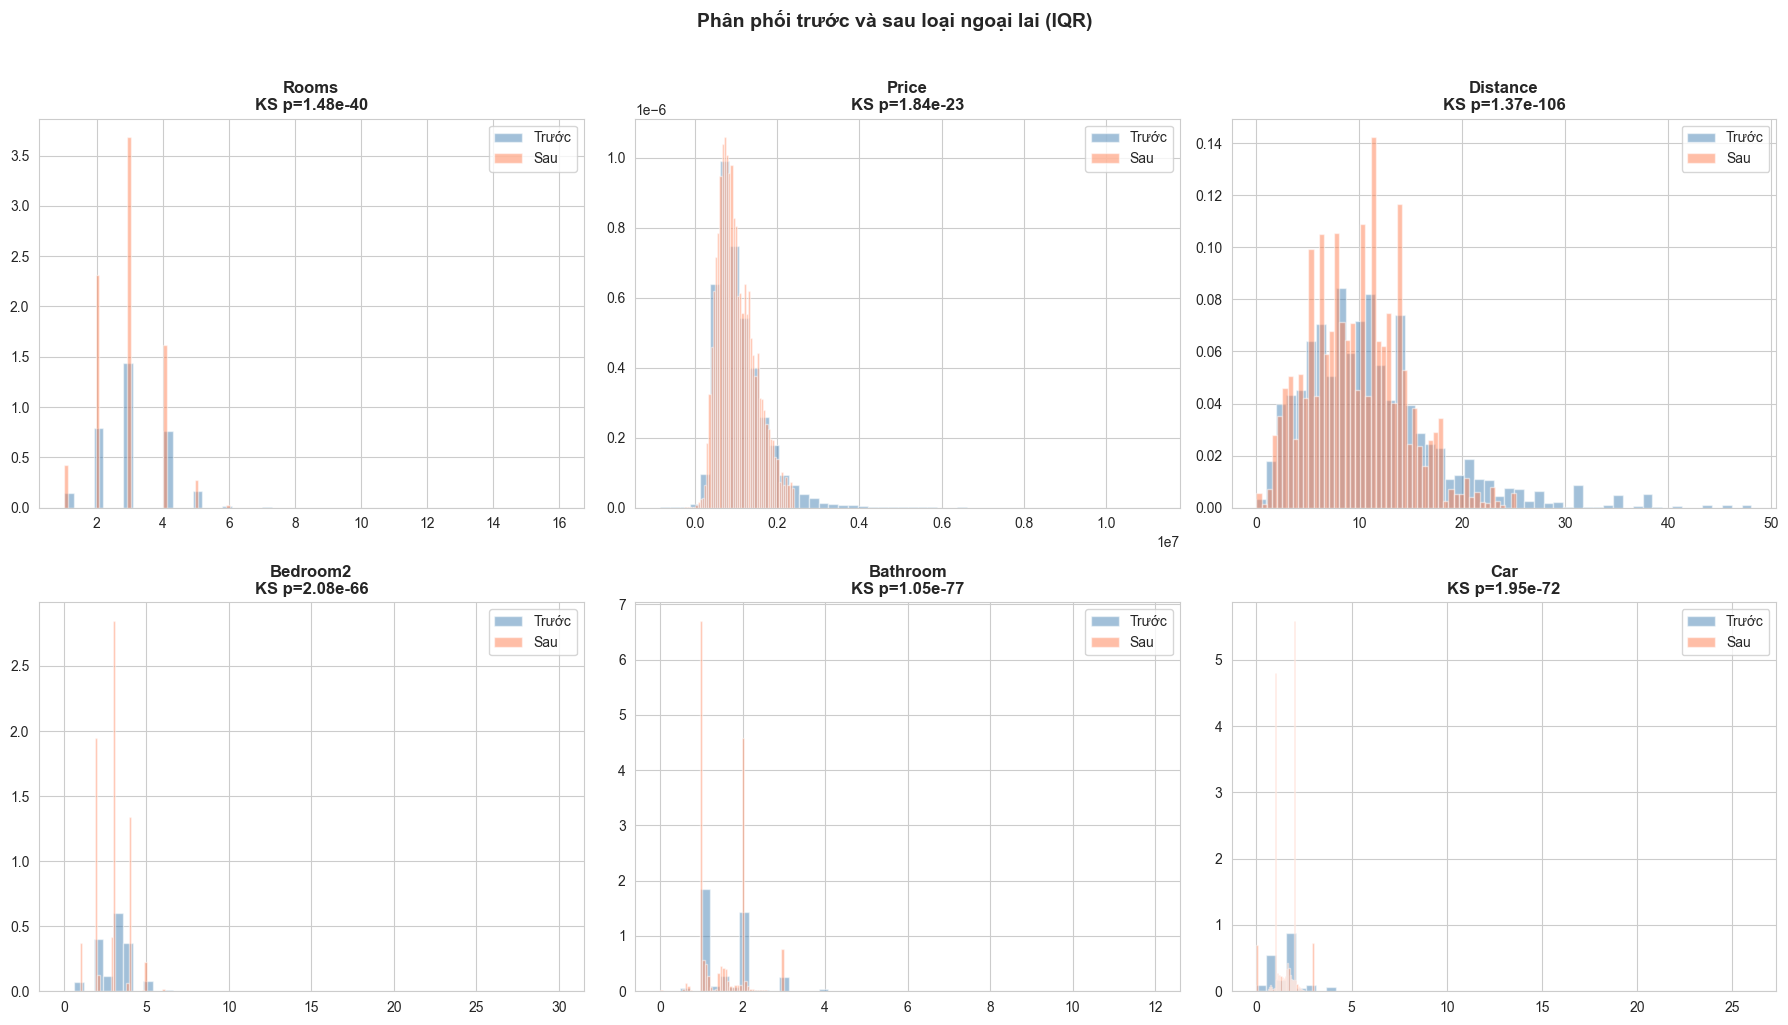

In [8]:
# Dùng IQR làm phương pháp tham chiếu để loại outlier
df_no_outlier = df_imputed[~outlier_masks['IQR']].copy()
print(f'Kích thước sau loại outlier (IQR): {df_no_outlier.shape} '
      f'(loại {outlier_masks["IQR"].sum()} hàng)')

# Kiểm định KS cho từng cột số
ks_results = []
for col in outlier_cols:
    stat, p = stats.ks_2samp(df_imputed[col], df_no_outlier[col])
    ks_results.append({'Column': col, 'KS_stat': stat, 'p_value': p,
                       'Significant': 'Có' if p < 0.05 else 'Không'})

ks_df = pd.DataFrame(ks_results)
print('\nKIỂM ĐỊNH KOLMOGOROV-SMIRNOV: phân phối trước vs sau loại ngoại lai')
print('(p < 0.05 → phân phối thay đổi đáng kể)')
display(ks_df)

# Trực quan
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
plot_cols = outlier_cols[:6]
for i, col in enumerate(plot_cols):
    ax = axes[i]
    ax.hist(df_imputed[col], bins=50, alpha=0.5, label='Trước', density=True, color='steelblue')
    ax.hist(df_no_outlier[col], bins=50, alpha=0.5, label='Sau', density=True, color='coral')
    p = ks_df[ks_df['Column'] == col]['p_value'].values[0]
    ax.set_title(f'{col}\nKS p={p:.2e}', fontweight='bold')
    ax.legend()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Phân phối trước và sau loại ngoại lai (IQR)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### B.4 – Phân tích kết quả phát hiện ngoại lai

**Nhận xét:**
- **IQR** phát hiện nhiều ngoại lai nhất – phương pháp bảo thủ cho dữ liệu phân phối lệch.
- **Z-score** nhạy hơn nhưng giả định phân phối chuẩn.
- **Isolation Forest** cho phép kiểm soát contamination; c=0.05 thường phù hợp.
- **LOF** phát hiện ngoại lai cục bộ – hữu ích khi dữ liệu có cụm mật độ khác nhau.
- **DBSCAN** coi noise points là ngoại lai – phụ thuộc nhiều vào eps và min_samples.
- Kiểm định KS cho thấy việc loại ngoại lai thay đổi phân phối đáng kể ở một số biến → 
  cần cân nhắc không loại quá nhiều.

---
# PHẦN C – Chuẩn hóa dữ liệu có kiểm định

## Lý thuyết

| Phương pháp | Công thức | Đặc điểm |
|------------|----------|----------|
| **Min-Max** | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | Co về [0,1], nhạy outlier |
| **Z-score** | $x' = \frac{x - \mu}{\sigma}$ | Mean=0, Std=1, giả định phân phối chuẩn |
| **Robust** | $x' = \frac{x - Q_2}{Q_3 - Q_1}$ | Dùng median & IQR, ít nhạy outlier |
| **Quantile (uniform)** | CDF transform → U[0,1] | Biến đổi sang phân phối đều |
| **Quantile (normal)** | CDF → Φ⁻¹ → N(0,1) | Biến đổi sang phân phối chuẩn |

### Kiểm định Levene's test
Đánh giá sự đồng nhất phương sai (homoscedasticity) giữa các nhóm.
- $H_0$: phương sai bằng nhau giữa các nhóm
- $p > 0.05$ → phương sai đồng nhất

### C.1 – Áp dụng các phương pháp chuẩn hóa

In [9]:
# Dữ liệu cần chuẩn hóa (dùng df_imputed, các cột số liên tục)
scale_cols = [c for c in numeric_cols if c not in ['Postcode', 'Propertycount']]
X_raw = df_imputed[scale_cols].copy()

scalers = {
    'Min-Max': MinMaxScaler(),
    'Z-score': StandardScaler(),
    'Robust': RobustScaler(),
    'Quantile-Uniform': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile-Normal': QuantileTransformer(output_distribution='normal', random_state=42),
}

scaled_dfs = {}
for name, sc in scalers.items():
    scaled_dfs[name] = pd.DataFrame(sc.fit_transform(X_raw),
                                     columns=scale_cols, index=X_raw.index)

# Thống kê mô tả sau chuẩn hóa
for name, sdf in scaled_dfs.items():
    print(f'\n=== {name} ===')
    display(sdf.describe().round(4))


=== Min-Max ===


,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude
count,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000
mean,0.1354,0.1609,0.2325,0.1005,0.1323,0.0650,0.0071,0.0145,0.1249,0.4757,0.5227
std,0.0647,0.0521,0.1411,0.0326,0.0563,0.0348,0.0064,0.0081,0.0081,0.1007,0.0978
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0667,0.1255,0.1331,0.0671,0.0833,0.0385,0.0064,0.0133,0.1224,0.4242,0.4773
50%,0.1333,0.1479,0.2141,0.1000,0.1246,0.0726,0.0070,0.0142,0.1250,0.4811,0.5234
75%,0.2000,0.1834,0.2911,0.1320,0.1667,0.0769,0.0073,0.0153,0.1275,0.5276,0.5729
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



=== Z-score ===


,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude
count,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000
mean,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-2.0940,-3.0855,-1.6476,-3.0839,-2.3520,-1.8681,-1.1105,-1.7866,-15.4550,-4.7236,-5.3465
25%,-1.0630,-0.6793,-0.7048,-1.0244,-0.8708,-0.7635,-0.1068,-0.1474,-0.3072,-0.5116,-0.4652
50%,-0.0320,-0.2496,-0.1304,-0.0168,-0.1376,0.2178,-0.0177,-0.0405,0.0194,0.0541,0.0064
75%,0.9990,0.4315,0.4147,0.9631,0.6103,0.3411,0.0356,0.0864,0.3279,0.5159,0.5125
max,13.3712,16.0937,5.4377,27.5868,15.4221,26.8516,155.7931,121.0176,108.2987,5.2065,4.8812



=== Robust ===


,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude
count,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000
mean,0.0155,0.2247,0.1164,0.0085,0.0929,-0.1972,0.1246,0.1731,-0.0305,-0.0527,-0.0065
std,0.4850,0.9003,0.8933,0.5031,0.6751,0.9053,7.0239,4.2768,1.5745,0.9733,1.0228
min,-1.0000,-2.5531,-1.3553,-1.5431,-1.4950,-1.8884,-7.6756,-7.4676,-24.3641,-4.6500,-5.4749
25%,-0.5000,-0.3868,-0.5132,-0.5070,-0.4950,-0.8884,-0.6255,-0.4575,-0.5142,-0.5506,-0.4824
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.5000,0.6132,0.4868,0.4930,0.5050,0.1116,0.3745,0.5425,0.4858,0.4494,0.5176
max,6.5000,14.7135,4.9737,13.8882,10.5050,24.1116,1094.3820,517.7381,170.4839,5.0146,4.9859



=== Quantile-Uniform ===


,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude
count,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000
mean,0.5021,0.5054,0.4988,0.5031,0.5017,0.5002,0.5032,0.5021,0.4948,0.4986,0.4990
std,0.2751,0.2891,0.2891,0.2814,0.2769,0.2832,0.2883,0.2887,0.2911,0.2872,0.2895
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.1627,0.2523,0.2513,0.2506,0.2077,0.1977,0.2566,0.2491,0.2431,0.2513,0.2469
50%,0.5025,0.5120,0.4965,0.5345,0.5041,0.5002,0.5020,0.5050,0.4891,0.4950,0.5002
75%,0.8318,0.7588,0.7508,0.7522,0.7377,0.6952,0.7548,0.7521,0.7496,0.7461,0.7487
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



=== Quantile-Normal ===


,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude
count,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000,34857.0000
mean,-0.1208,0.0164,-0.0060,0.0060,0.0194,-0.1404,0.0144,0.0052,-0.0146,-0.0005,-0.0041
std,1.3425,1.0007,1.0242,0.9633,0.9211,1.4005,0.9896,0.9962,1.0064,1.0026,1.0028
min,-5.1993,-5.1993,-5.1993,-5.1993,-5.1993,-5.1993,-5.1993,-5.1993,-5.1993,-5.1993,-5.1993
25%,-0.9836,-0.6674,-0.6706,-0.6727,-0.8144,-0.8499,-0.6539,-0.6773,-0.6962,-0.6706,-0.6842
50%,0.0063,0.0301,-0.0088,0.0867,0.0103,0.0004,0.0050,0.0126,-0.0273,-0.0126,0.0005
75%,0.9614,0.7024,0.6769,0.6815,0.6364,0.5106,0.6895,0.6812,0.6733,0.6621,0.6704
max,5.1993,5.1993,5.1993,5.1993,5.1993,5.1993,5.1993,5.1993,5.1993,5.1993,5.1993


### C.2 – Kiểm định Levene's test

In [10]:
# Levene's test: so sánh phương sai giữa các cột sau mỗi phương pháp chuẩn hóa
# Chia dữ liệu theo nhóm Type (h/u/t) để kiểm tra homoscedasticity
groups_col = 'Type'
groups = df_imputed[groups_col].unique()
print(f'Nhóm dùng cho Levene test: {groups_col} = {groups}')

levene_results = []

for scaler_name, sdf in scaled_dfs.items():
    sdf_with_group = sdf.copy()
    sdf_with_group[groups_col] = df_imputed[groups_col].values
    for col in scale_cols:
        group_data = [sdf_with_group[sdf_with_group[groups_col] == g][col].dropna()
                      for g in groups]
        # Cần ít nhất 2 nhóm có dữ liệu
        group_data = [g for g in group_data if len(g) > 0]
        if len(group_data) >= 2:
            stat, p = stats.levene(*group_data)
            levene_results.append({
                'Scaler': scaler_name, 'Column': col,
                'Levene_stat': round(stat, 4), 'p_value': round(p, 6),
                'Homoscedastic': 'Có' if p > 0.05 else 'Không'
            })

levene_df = pd.DataFrame(levene_results)
print('\nKẾT QUẢ LEVENE TEST (Đồng nhất phương sai theo nhóm Type)')
display(levene_df)

# Tỷ lệ homoscedastic cho mỗi scaler
homo_summary = levene_df.groupby('Scaler')['Homoscedastic'].apply(
    lambda x: (x == 'Có').sum() / len(x) * 100
).round(1)
print('\nTỈ LỆ CỘT CÓ PHƯƠNG SAI ĐỒNG NHẤT (%)')
print(homo_summary.to_string())

Nhóm dùng cho Levene test: Type = ['h' 'u' 't']

KẾT QUẢ LEVENE TEST (Đồng nhất phương sai theo nhóm Type)


,Scaler,Column,Levene_stat,p_value,Homoscedastic
0,Min-Max,Rooms,349.9697,0.000000,Không
1,Min-Max,Price,1107.2161,0.000000,Không
2,Min-Max,Distance,280.5585,0.000000,Không
3,Min-Max,Bedroom2,320.6675,0.000000,Không
4,Min-Max,Bathroom,1366.1296,0.000000,Không
5,Min-Max,Car,657.1401,0.000000,Không
6,Min-Max,Landsize,4.8945,0.007492,Không
7,Min-Max,BuildingArea,7.3991,0.000613,Không
8,Min-Max,YearBuilt,180.7343,0.000000,Không
9,Min-Max,Lattitude,864.2841,0.000000,Không



TỈ LỆ CỘT CÓ PHƯƠNG SAI ĐỒNG NHẤT (%)
Scaler
Min-Max             0.0
Quantile-Normal     0.0
Quantile-Uniform    0.0
Robust              0.0
Z-score             0.0


### C.3 – Violin plot phân phối sau chuẩn hóa

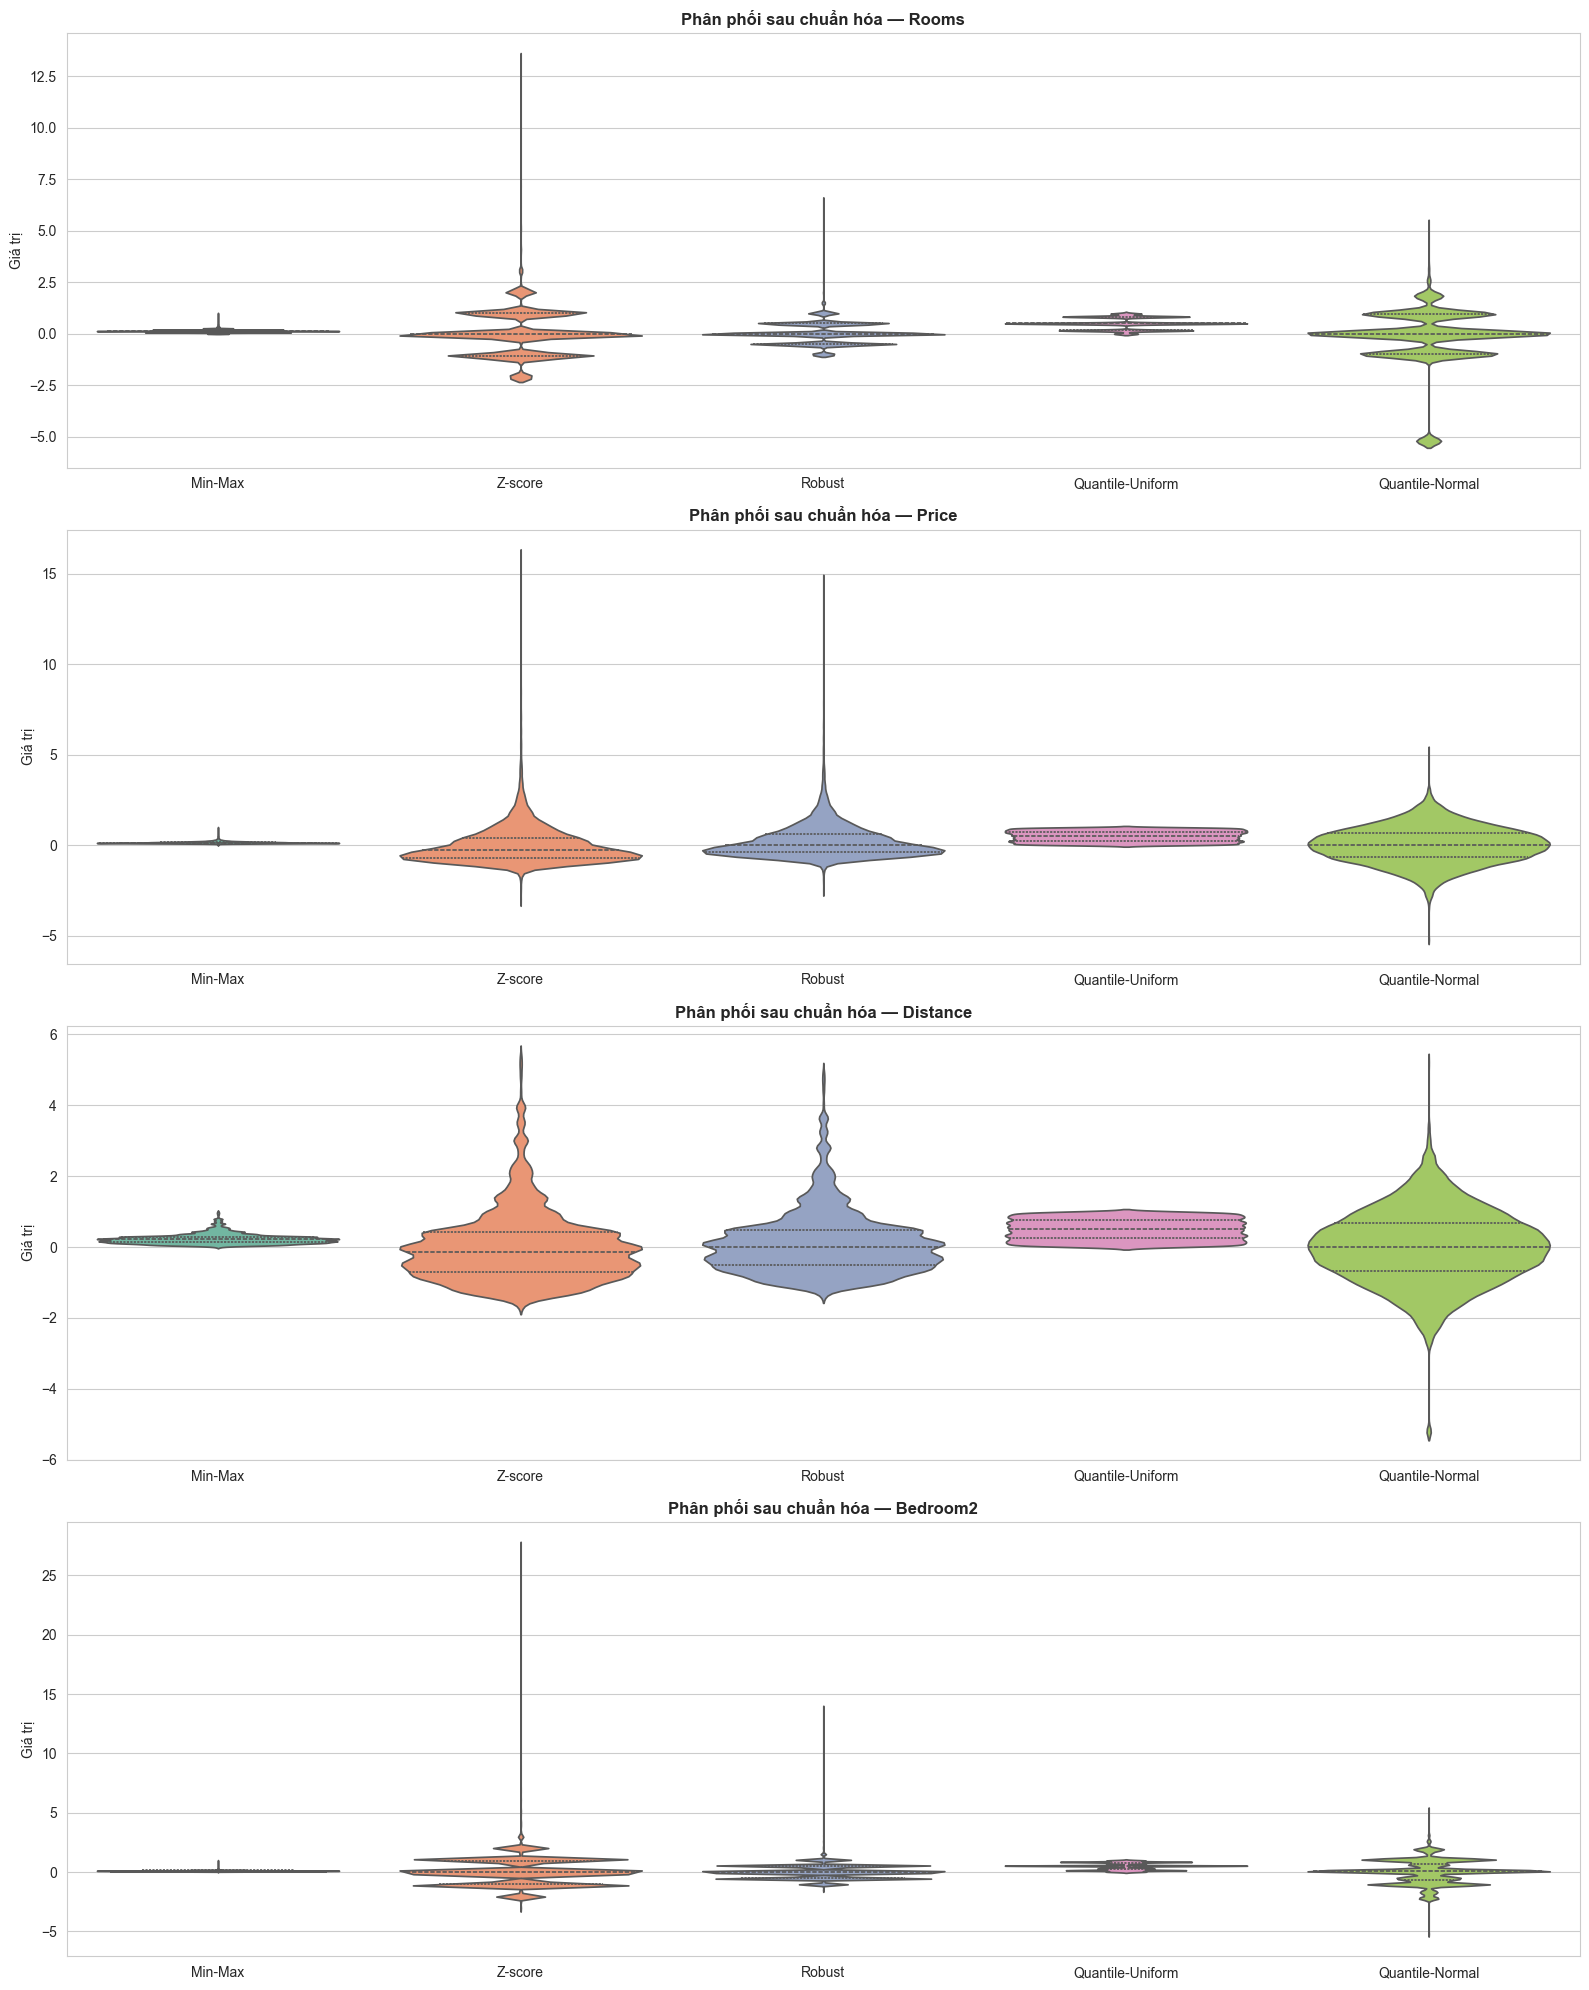

In [11]:
# Violin plot cho 3 cột đại diện, so sánh 5 phương pháp
demo_cols = scale_cols[:4]  # Lấy 4 cột đầu

fig, axes = plt.subplots(len(demo_cols), 1, figsize=(16, 5 * len(demo_cols)))
if len(demo_cols) == 1:
    axes = [axes]

for idx, col in enumerate(demo_cols):
    ax = axes[idx]
    plot_data = []
    for sname, sdf in scaled_dfs.items():
        tmp = pd.DataFrame({'value': sdf[col], 'Scaler': sname})
        plot_data.append(tmp)
    plot_df = pd.concat(plot_data, ignore_index=True)
    sns.violinplot(data=plot_df, x='Scaler', y='value', ax=ax,
                   palette='Set2', inner='quartile')
    ax.set_title(f'Phân phối sau chuẩn hóa — {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Giá trị')

plt.tight_layout()
plt.show()

### C.4 – Phân tích kết quả chuẩn hóa

**Nhận xét:**
- **Min-Max**: Co dữ liệu về [0,1] nhưng outlier bị nén, phần lớn dữ liệu tập trung gần 0.
- **Z-score**: Hoạt động tốt nếu dữ liệu gần chuẩn; outlier vẫn có z-score lớn.
- **Robust Scaling**: Ít bị ảnh hưởng bởi outlier, phân phối cân đối hơn Min-Max.
- **Quantile (uniform)**: Biến đổi mọi phân phối thành đều – hữu ích cho các mô hình non-parametric.
- **Quantile (normal)**: Ép phân phối thành dạng chuẩn – tốt cho các mô hình yêu cầu Gaussian input.
- Levene's test cho thấy mức độ đồng nhất phương sai thay đổi tùy phương pháp.

---
# PHẦN D – Mã hóa biến phân loại nâng cao

## Lý thuyết

| Phương pháp | Mô tả | Ưu điểm | Nhược điểm |
|------------|-------|---------|------------|
| **One-Hot** | Mỗi giá trị → 1 cột nhị phân | Không giả định thứ tự | Chiều cao nếu high-cardinality |
| **Ordinal** | Gán số nguyên theo thứ tự | Giữ nguyên 1 cột | Cần thứ tự có ý nghĩa |
| **Target Encoding** | Thay bằng mean(target) theo nhóm | Compact, mạnh | Dễ bị target leakage |
| **Binary Encoding** | Ordinal → mã nhị phân → tách cột | Ít cột hơn One-Hot | Ít phổ biến |
| **Frequency Encoding** | Thay bằng tần suất xuất hiện | Đơn giản | Các nhóm cùng tần suất bị trùng |

### D.1 – Xác định biến phân loại và đặc điểm

In [12]:
# Loại bỏ Address (quá nhiều unique) và Date (sẽ xử lý riêng)
encode_cols = [c for c in cat_cols if c not in ['Address', 'Date']]
print('Các cột phân loại sẽ mã hóa:')
for c in encode_cols:
    nu = df_imputed[c].nunique()
    card = 'HIGH-CARD' if nu > 20 else 'low-card'
    print(f'  {c:20s}: {nu:5d} giá trị duy nhất  [{card}]')

# Biến target: Price
target_col = 'Price'
y = df_imputed[target_col].copy()

Các cột phân loại sẽ mã hóa:
  Suburb              :   351 giá trị duy nhất  [HIGH-CARD]
  Type                :     3 giá trị duy nhất  [low-card]
  Method              :     9 giá trị duy nhất  [low-card]
  SellerG             :   388 giá trị duy nhất  [HIGH-CARD]
  CouncilArea         :    33 giá trị duy nhất  [HIGH-CARD]
  Regionname          :     8 giá trị duy nhất  [low-card]


### D.2 – One-Hot Encoding

In [13]:
# One-Hot cho các cột low-cardinality
low_card = [c for c in encode_cols if df_imputed[c].nunique() <= 20]
print(f'One-Hot Encoding cho: {low_card}')

df_onehot = pd.get_dummies(df_imputed[low_card], drop_first=True)
print(f'Số cột sau One-Hot: {df_onehot.shape[1]}')
display(df_onehot.head())

One-Hot Encoding cho: ['Type', 'Method', 'Regionname']
Số cột sau One-Hot: 17


,Type_t,Type_u,Method_PN,Method_S,Method_SA,Method_SN,Method_SP,Method_SS,Method_VB,Method_W,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False


### D.3 – Ordinal Encoding

In [14]:
# Ordinal Encoding cho Type (h < t < u theo kích thước)
ordinal_map = {'Type': ['h', 't', 'u']}  # house < townhouse < unit
df_ordinal = df_imputed[['Type']].copy()
oe = OrdinalEncoder(categories=[ordinal_map['Type']])
df_ordinal['Type_ordinal'] = oe.fit_transform(df_ordinal[['Type']])
print('Ordinal Encoding cho Type:')
display(df_ordinal.drop_duplicates().sort_values('Type_ordinal'))

Ordinal Encoding cho Type:


,Type,Type_ordinal
0,h,0.0
16,t,1.0
3,u,2.0


### D.4 – Target Encoding (Mean Encoding) với Cross-Validation

Để tránh **target leakage**, ta dùng K-Fold cross-validation:
- Trong mỗi fold, chỉ dùng dữ liệu training để tính mean(target) cho mỗi category.
- Áp dụng lên validation fold.

In [15]:
# Target Encoding với 5-fold CV để tránh target leakage
target_encode_cols = [c for c in encode_cols if df_imputed[c].nunique() > 2]
print(f'Target Encoding cho: {target_encode_cols}')

df_target_enc = df_imputed[target_encode_cols].copy()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in target_encode_cols:
    df_target_enc[f'{col}_target'] = np.nan
    for train_idx, val_idx in kf.split(df_imputed):
        means = df_imputed.iloc[train_idx].groupby(col)[target_col].mean()
        df_target_enc.loc[df_imputed.index[val_idx], f'{col}_target'] = (
            df_imputed.iloc[val_idx][col].map(means)
        )
    # Điền NaN còn lại bằng global mean
    df_target_enc[f'{col}_target'].fillna(y.mean(), inplace=True)

target_enc_result = df_target_enc[[f'{c}_target' for c in target_encode_cols]]
print(f'Số cột sau Target Encoding: {target_enc_result.shape[1]}')
display(target_enc_result.head())

Target Encoding cho: ['Suburb', 'Type', 'Method', 'SellerG', 'CouncilArea', 'Regionname']
Số cột sau Target Encoding: 6


,Suburb_target,Type_target,Method_target,SellerG_target,CouncilArea_target,Regionname_target
0,1.131882e+06,1.232470e+06,1.121695e+06,1.371145e+06,1.154867e+06,896189.129979
1,1.135182e+06,1.236351e+06,1.091576e+06,1.061786e+06,1.158666e+06,892944.692888
2,1.135182e+06,1.236351e+06,1.091576e+06,1.061786e+06,1.158666e+06,892944.692888
3,1.131882e+06,6.612711e+05,1.194844e+06,1.065943e+06,1.154867e+06,896189.129979
4,1.119771e+06,1.239767e+06,9.891663e+05,1.056550e+06,1.153087e+06,899224.302419


### D.5 – Binary Encoding (cho high-cardinality)

In [16]:
# Binary Encoding cho cột high-cardinality (> 20 giá trị)
high_card = [c for c in encode_cols if df_imputed[c].nunique() > 20]
print(f'Binary Encoding cho: {high_card}')

if high_card:
    bin_enc = ce.BinaryEncoder(cols=high_card)
    df_binary = bin_enc.fit_transform(df_imputed[high_card])
    print(f'Số cột sau Binary Encoding: {df_binary.shape[1]}')
    display(df_binary.head())
else:
    print('Không có cột high-cardinality (> 20 giá trị).')
    df_binary = pd.DataFrame()

Binary Encoding cho: ['Suburb', 'SellerG', 'CouncilArea']
Số cột sau Binary Encoding: 24


,Suburb_0,Suburb_1,Suburb_2,Suburb_3,Suburb_4,Suburb_5,Suburb_6,Suburb_7,Suburb_8,SellerG_0,...,SellerG_5,SellerG_6,SellerG_7,SellerG_8,CouncilArea_0,CouncilArea_1,CouncilArea_2,CouncilArea_3,CouncilArea_4,CouncilArea_5
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,1,0,...,0,0,1,1,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1


### D.6 – Frequency Encoding

In [17]:
# Frequency Encoding: thay mỗi category bằng tần suất xuất hiện
df_freq = pd.DataFrame(index=df_imputed.index)
for col in encode_cols:
    freq = df_imputed[col].value_counts(normalize=True)
    df_freq[f'{col}_freq'] = df_imputed[col].map(freq)

print(f'Số cột sau Frequency Encoding: {df_freq.shape[1]}')
display(df_freq.head())

Số cột sau Frequency Encoding: 6


,Suburb_freq,Type_freq,Method_freq,SellerG_freq,CouncilArea_freq,Regionname_freq
0,0.00393,0.687954,0.001033,0.096365,0.034025,0.274177
1,0.00393,0.687954,0.566429,0.025734,0.034025,0.274177
2,0.00393,0.687954,0.566429,0.025734,0.034025,0.274177
3,0.00393,0.209341,0.089164,0.000258,0.034025,0.274177
4,0.00393,0.687954,0.146169,0.025734,0.034025,0.274177


### D.7 – Kiểm tra đa cộng tuyến (VIF) sau mã hóa

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(df_enc, label=''):
    """Tính VIF cho dataframe đã encode."""
    # Chỉ lấy tối đa 20 cột để tránh quá lâu
    cols = df_enc.columns[:20] if len(df_enc.columns) > 20 else df_enc.columns
    X = df_enc[cols].dropna()
    if X.shape[1] < 2:
        print(f'  {label}: Cần ít nhất 2 cột.')
        return pd.DataFrame()
    vif_data = pd.DataFrame()
    vif_data['Feature'] = cols
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
    vif_data = vif_data.sort_values('VIF', ascending=False)
    return vif_data

print('VIF — ONE-HOT ENCODING')
vif_onehot = calc_vif(df_onehot, 'One-Hot')
display(vif_onehot)

print('\nVIF — TARGET ENCODING')
vif_target = calc_vif(target_enc_result, 'Target')
display(vif_target)

print('\nVIF — BINARY ENCODING')
if not df_binary.empty:
    vif_binary = calc_vif(df_binary, 'Binary')
    display(vif_binary)

print('\nVIF — FREQUENCY ENCODING')
vif_freq = calc_vif(df_freq, 'Frequency')
display(vif_freq)

print('\n⚠ VIF > 10 → nghi ngờ đa cộng tuyến cao. Cần xem xét loại bỏ hoặc kết hợp biến.')

VIF — ONE-HOT ENCODING


,Feature,VIF
7,Method_SS,0.027853
16,Regionname_Western Victoria,0.008818
9,Method_W,0.005916
12,Regionname_Northern Victoria,0.005048
4,Method_SA,0.004522
10,Regionname_Eastern Victoria,0.004496
2,Method_PN,0.003351
5,Method_SN,0.000842
13,Regionname_South-Eastern Metropolitan,0.000678
8,Method_VB,0.000428



VIF — TARGET ENCODING


,Feature,VIF
4,CouncilArea_target,74.936489
5,Regionname_target,55.473438
2,Method_target,48.017572
0,Suburb_target,42.122062
3,SellerG_target,24.105265
1,Type_target,22.282392



VIF — BINARY ENCODING


,Feature,VIF
19,CouncilArea_1,2.460492
17,SellerG_8,2.204354
15,SellerG_6,2.176378
1,Suburb_1,2.111944
4,Suburb_4,2.063450
6,Suburb_6,2.017780
2,Suburb_2,1.927317
13,SellerG_4,1.915793
8,Suburb_8,1.878741
7,Suburb_7,1.852966



VIF — FREQUENCY ENCODING


,Feature,VIF
5,Regionname_freq,9.752912
4,CouncilArea_freq,8.658187
0,Suburb_freq,4.441511
1,Type_freq,3.906773
2,Method_freq,3.355267
3,SellerG_freq,2.639223



⚠ VIF > 10 → nghi ngờ đa cộng tuyến cao. Cần xem xét loại bỏ hoặc kết hợp biến.


### D.8 – Phân tích kết quả mã hóa

**Nhận xét:**
- **One-Hot**: Tạo nhiều cột cho Suburb (351), SellerG (388) → chiều rất cao → chỉ nên dùng cho cột ít giá trị (Type, Method, Regionname).
- **Ordinal**: Phù hợp cho Type (house < townhouse < unit) – có thứ tự tự nhiên.
- **Target Encoding**: Compact (1 cột/biến), sử dụng 5-fold CV để tránh target leakage. Có thể gây đa cộng tuyến nếu nhiều biến encode cùng target.
- **Binary Encoding**: Tốt cho Suburb, SellerG – giảm số cột đáng kể so với One-Hot (log₂(n) cột thay vì n cột).
- **Frequency Encoding**: Đơn giản nhất, nhưng các category có cùng tần suất sẽ trùng giá trị → mất thông tin.
- **VIF** cho thấy mức độ đa cộng tuyến mới phát sinh từ mỗi phương pháp. One-Hot thường có VIF cao hơn.

---
# PHẦN E – Lựa chọn và giảm chiều đặc trưng

## Lý thuyết

### Ba tầng lọc đặc trưng

| Tầng | Phương pháp | Mô tả |
|------|-----------|-------|
| **Lọc thống kê** | ANOVA F-test, Chi-square, Mutual Information | Đánh giá mối quan hệ đơn biến giữa feature và target |
| **Lọc dựa trên mô hình** | RF/GB Feature Importance, RFECV | Sử dụng mô hình để đánh giá tầm quan trọng |
| **Giảm chiều** | PCA, t-SNE, UMAP | Chuyển đổi không gian đặc trưng sang chiều thấp hơn |

### Đánh giá
Với mỗi phương pháp lọc, huấn luyện mô hình trên tập đặc trưng được chọn và báo cáo **5-fold cross-validation F1-score**.

### E.1 – Chuẩn bị dữ liệu cho Feature Selection

In [19]:
from sklearn.feature_selection import (
    f_classif, chi2, mutual_info_classif,
    SelectKBest, RFECV
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder as LE_fs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- Chuẩn bị dữ liệu ---
# Tạo biến target phân loại từ Type (h, t, u)
target_fs = 'Type'
le_fs = LE_fs()
y_fs = le_fs.fit_transform(df_imputed[target_fs])
print(f'Target: {target_fs} → classes = {le_fs.classes_}')
print(f'Phân phối: {dict(zip(*np.unique(y_fs, return_counts=True)))}')

# Tạo tập đặc trưng: cột số + frequency-encoded cột phân loại
feature_cols_num = [c for c in numeric_cols if c != 'Price']
X_fs_num = df_imputed[feature_cols_num].copy()

# Encode biến phân loại bằng frequency
cat_for_fs = [c for c in cat_cols if c not in ['Address', 'Date', target_fs]]
for col in cat_for_fs:
    freq = df_imputed[col].value_counts(normalize=True)
    X_fs_num[f'{col}_freq'] = df_imputed[col].map(freq)

# Điền NaN còn sót và scale
X_fs_num = X_fs_num.fillna(X_fs_num.median())
scaler_fs = StandardScaler()
X_fs_scaled = pd.DataFrame(scaler_fs.fit_transform(X_fs_num),
                           columns=X_fs_num.columns, index=X_fs_num.index)

print(f'\nSố đặc trưng: {X_fs_scaled.shape[1]}')
print(f'Tên đặc trưng: {list(X_fs_scaled.columns)}')

Target: Type → classes = ['h' 't' 'u']
Phân phối: {np.int64(0): np.int64(23980), np.int64(1): np.int64(3580), np.int64(2): np.int64(7297)}

Số đặc trưng: 17
Tên đặc trưng: ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount', 'Suburb_freq', 'Method_freq', 'SellerG_freq', 'CouncilArea_freq', 'Regionname_freq']


### E.2 – Tầng 1: Lọc thống kê (ANOVA F-test, Chi-square, Mutual Information)

=== ANOVA F-test ===


,Feature,F_score,p_value
0,Rooms,7771.900954,0.000000e+00
3,Bedroom2,7182.338608,0.000000e+00
4,Bathroom,2021.951129,0.000000e+00
5,Car,1701.732437,0.000000e+00
1,Distance,1035.181984,0.000000e+00
16,Regionname_freq,612.632667,3.212484e-262
8,YearBuilt,285.307524,1.246985e-123
12,Suburb_freq,216.063015,5.520171e-94
15,CouncilArea_freq,136.716719,7.184147e-60
7,BuildingArea,117.371011,1.575086e-51



=== Chi-square test ===


,Feature,Chi2_score,p_value
0,Rooms,331.973012,8.184203e-73
1,Distance,167.423792,4.409460e-37
16,Regionname_freq,120.580937,6.549110e-27
3,Bedroom2,107.556594,4.409428e-24
4,Bathroom,86.683062,1.503184e-19
12,Suburb_freq,63.173937,1.914053e-14
5,Car,57.797606,2.814553e-13
15,CouncilArea_freq,33.201478,6.171499e-08
11,Propertycount,28.282897,7.218501e-07
13,Method_freq,25.824808,2.467256e-06



=== Mutual Information ===


,Feature,MI_score
3,Bedroom2,0.253047
0,Rooms,0.213035
6,Landsize,0.196336
7,BuildingArea,0.174071
5,Car,0.162156
4,Bathroom,0.151221
11,Propertycount,0.111455
8,YearBuilt,0.104912
2,Postcode,0.103168
10,Longtitude,0.096323


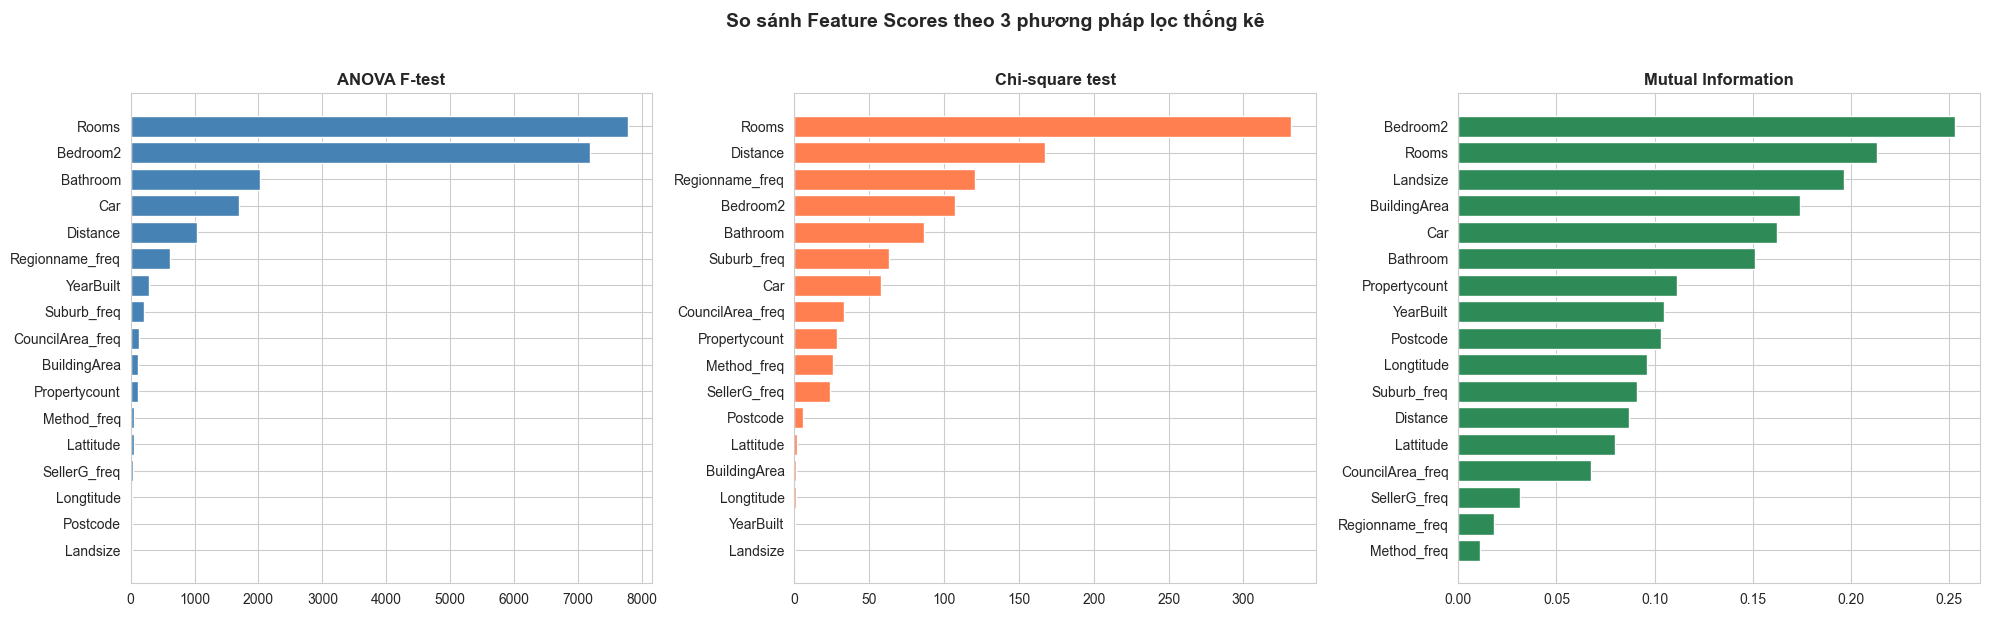

In [20]:
# === ANOVA F-test (cho thuộc tính số) ===
f_scores, f_pvalues = f_classif(X_fs_scaled, y_fs)
anova_df = pd.DataFrame({
    'Feature': X_fs_scaled.columns,
    'F_score': f_scores,
    'p_value': f_pvalues
}).sort_values('F_score', ascending=False)

print('=== ANOVA F-test ===')
display(anova_df)

# === Chi-square test (cần dữ liệu >= 0) ===
from sklearn.preprocessing import MinMaxScaler as MMS_chi2
X_chi2 = MMS_chi2().fit_transform(X_fs_num)  # Chi2 cần non-negative
chi2_scores, chi2_pvalues = chi2(X_chi2, y_fs)
chi2_df = pd.DataFrame({
    'Feature': X_fs_num.columns,
    'Chi2_score': chi2_scores,
    'p_value': chi2_pvalues
}).sort_values('Chi2_score', ascending=False)

print('\n=== Chi-square test ===')
display(chi2_df)

# === Mutual Information ===
mi_scores = mutual_info_classif(X_fs_scaled, y_fs, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_fs_scaled.columns,
    'MI_score': mi_scores
}).sort_values('MI_score', ascending=False)

print('\n=== Mutual Information ===')
display(mi_df)

# --- Trực quan so sánh 3 phương pháp ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].barh(anova_df['Feature'], anova_df['F_score'], color='steelblue')
axes[0].set_title('ANOVA F-test', fontweight='bold')
axes[0].invert_yaxis()

axes[1].barh(chi2_df['Feature'], chi2_df['Chi2_score'], color='coral')
axes[1].set_title('Chi-square test', fontweight='bold')
axes[1].invert_yaxis()

axes[2].barh(mi_df['Feature'], mi_df['MI_score'], color='seagreen')
axes[2].set_title('Mutual Information', fontweight='bold')
axes[2].invert_yaxis()

plt.suptitle('So sánh Feature Scores theo 3 phương pháp lọc thống kê',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### E.3 – Tầng 2: Lọc dựa trên mô hình (Random Forest, Gradient Boosting)

=== Random Forest Feature Importance ===


,Feature,RF_importance
3,Bedroom2,0.149628
6,Landsize,0.122338
8,YearBuilt,0.113279
7,BuildingArea,0.089122
0,Rooms,0.087331
5,Car,0.064530
9,Lattitude,0.053999
10,Longtitude,0.052551
4,Bathroom,0.048467
1,Distance,0.041510



=== Gradient Boosting Feature Importance ===


,Feature,GB_importance
3,Bedroom2,0.276978
0,Rooms,0.202175
8,YearBuilt,0.143603
6,Landsize,0.127738
7,BuildingArea,0.046134
2,Postcode,0.036344
5,Car,0.034771
4,Bathroom,0.032318
1,Distance,0.024621
10,Longtitude,0.021495


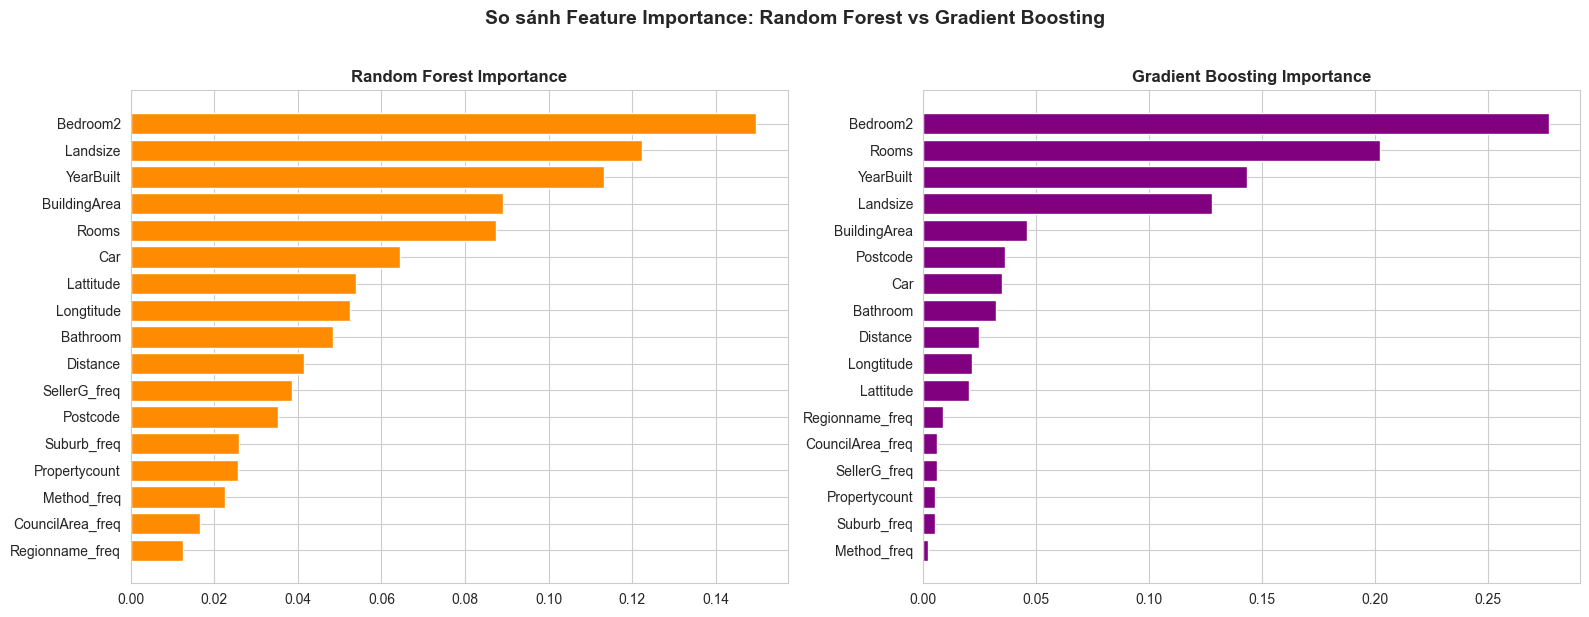

In [21]:
# === Random Forest Feature Importance ===
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fs.fit(X_fs_scaled, y_fs)
rf_imp = pd.DataFrame({
    'Feature': X_fs_scaled.columns,
    'RF_importance': rf_fs.feature_importances_
}).sort_values('RF_importance', ascending=False)

print('=== Random Forest Feature Importance ===')
display(rf_imp)

# === Gradient Boosting Feature Importance ===
gb_fs = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_fs.fit(X_fs_scaled, y_fs)
gb_imp = pd.DataFrame({
    'Feature': X_fs_scaled.columns,
    'GB_importance': gb_fs.feature_importances_
}).sort_values('GB_importance', ascending=False)

print('\n=== Gradient Boosting Feature Importance ===')
display(gb_imp)

# --- Trực quan so sánh RF vs GB ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(rf_imp['Feature'], rf_imp['RF_importance'], color='darkorange')
axes[0].set_title('Random Forest Importance', fontweight='bold')
axes[0].invert_yaxis()

axes[1].barh(gb_imp['Feature'], gb_imp['GB_importance'], color='purple')
axes[1].set_title('Gradient Boosting Importance', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('So sánh Feature Importance: Random Forest vs Gradient Boosting',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### E.4 – Recursive Feature Elimination với Cross-Validation (RFECV)

Đang chạy RFECV (có thể mất vài phút)...
Số đặc trưng tối ưu: 16
Đặc trưng được chọn: ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount', 'Suburb_freq', 'Method_freq', 'SellerG_freq', 'CouncilArea_freq']


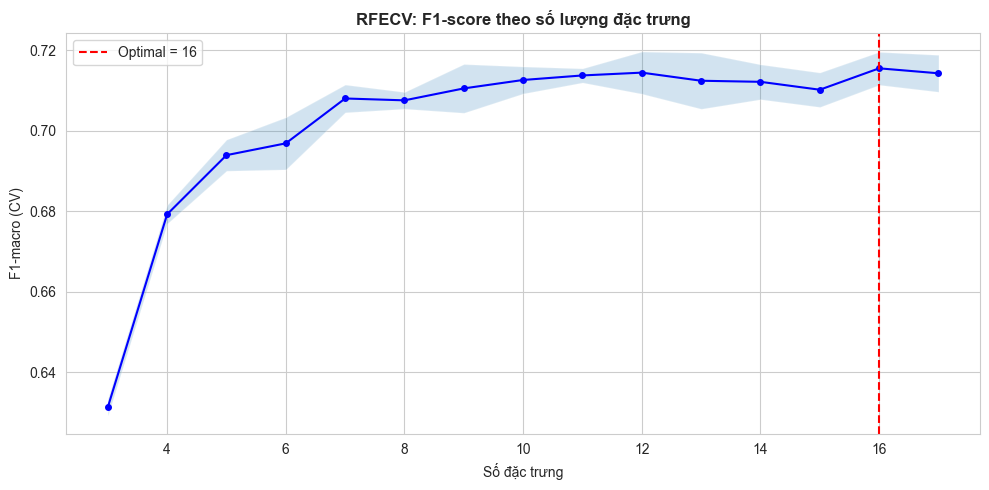

In [22]:
# === RFECV với Random Forest ===
print('Đang chạy RFECV (có thể mất vài phút)...')
rf_rfecv = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
skf_rfe = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(estimator=rf_rfecv, step=1, cv=skf_rfe, scoring='f1_macro',
              min_features_to_select=3, n_jobs=-1)
rfecv.fit(X_fs_scaled, y_fs)

print(f'Số đặc trưng tối ưu: {rfecv.n_features_}')
selected_features_rfe = X_fs_scaled.columns[rfecv.support_].tolist()
print(f'Đặc trưng được chọn: {selected_features_rfe}')

# Biểu đồ RFECV
fig, ax = plt.subplots(figsize=(10, 5))
cv_results_rfe = rfecv.cv_results_
n_feat_range = range(rfecv.min_features_to_select,
                     len(cv_results_rfe['mean_test_score']) + rfecv.min_features_to_select)
ax.plot(n_feat_range, cv_results_rfe['mean_test_score'], 'b-o', markersize=4)
ax.fill_between(n_feat_range,
                cv_results_rfe['mean_test_score'] - cv_results_rfe['std_test_score'],
                cv_results_rfe['mean_test_score'] + cv_results_rfe['std_test_score'],
                alpha=0.2)
ax.axvline(rfecv.n_features_, color='red', linestyle='--',
           label=f'Optimal = {rfecv.n_features_}')
ax.set_xlabel('Số đặc trưng')
ax.set_ylabel('F1-macro (CV)')
ax.set_title('RFECV: F1-score theo số lượng đặc trưng', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### E.5 – So sánh hiệu năng F1-score theo số lượng đặc trưng

Đang đánh giá F1-score theo K...


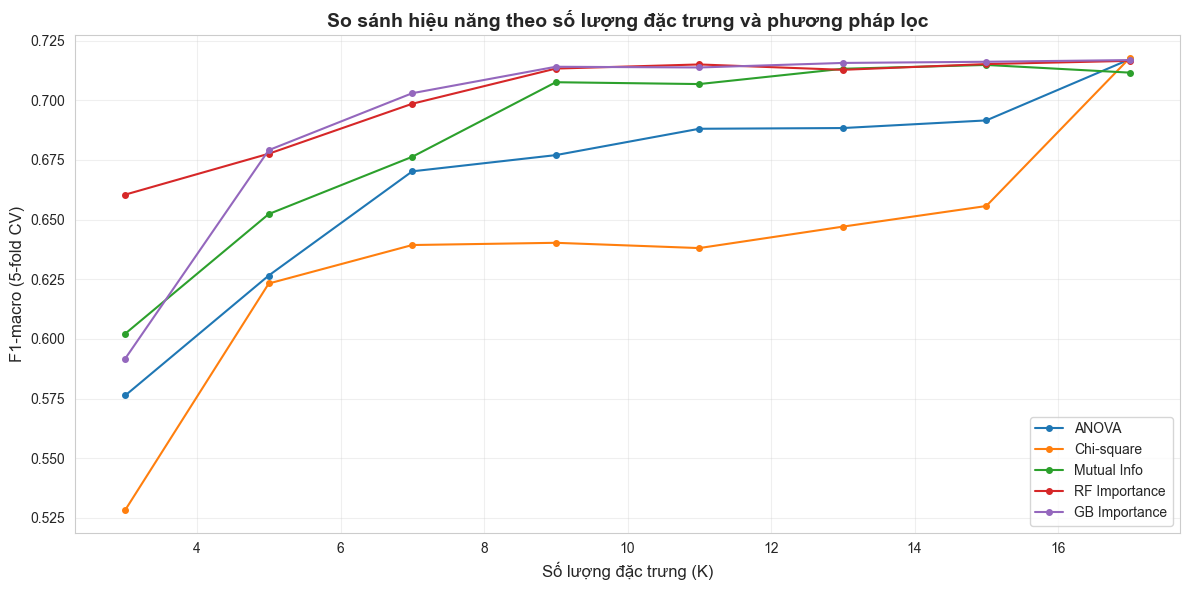


BẢNG TỔNG HỢP F1-SCORE TỐT NHẤT


,Method,Best_F1,Best_K
1,Chi-square,0.717715,17
0,ANOVA,0.717155,17
4,GB Importance,0.716816,17
3,RF Importance,0.716497,17
2,Mutual Info,0.714781,15


In [23]:
# Đánh giá F1-score (5-fold CV) khi chọn top-K đặc trưng theo mỗi phương pháp
k_values = list(range(3, X_fs_scaled.shape[1] + 1, 2))
if X_fs_scaled.shape[1] not in k_values:
    k_values.append(X_fs_scaled.shape[1])
k_values = sorted(set(k_values))

skf_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_eval = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Ranking features theo mỗi phương pháp
rankings = {
    'ANOVA': anova_df.set_index('Feature')['F_score'].reindex(X_fs_scaled.columns).values,
    'Chi-square': chi2_df.set_index('Feature')['Chi2_score'].reindex(X_fs_scaled.columns).values,
    'Mutual Info': mi_df.set_index('Feature')['MI_score'].reindex(X_fs_scaled.columns).values,
    'RF Importance': rf_imp.set_index('Feature')['RF_importance'].reindex(X_fs_scaled.columns).values,
    'GB Importance': gb_imp.set_index('Feature')['GB_importance'].reindex(X_fs_scaled.columns).values,
}

f1_results = {name: [] for name in rankings}

print('Đang đánh giá F1-score theo K...')
for name, scores in rankings.items():
    ranked_idx = np.argsort(scores)[::-1]
    for k in k_values:
        top_k_idx = ranked_idx[:k]
        X_k = X_fs_scaled.iloc[:, top_k_idx]
        f1 = cross_val_score(clf_eval, X_k, y_fs, cv=skf_eval,
                             scoring='f1_macro').mean()
        f1_results[name].append(f1)

# --- Biểu đồ so sánh ---
fig, ax = plt.subplots(figsize=(12, 6))
for name, f1_list in f1_results.items():
    ax.plot(k_values, f1_list, '-o', label=name, markersize=4)

ax.set_xlabel('Số lượng đặc trưng (K)', fontsize=12)
ax.set_ylabel('F1-macro (5-fold CV)', fontsize=12)
ax.set_title('So sánh hiệu năng theo số lượng đặc trưng và phương pháp lọc',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Bảng tổng hợp F1 tốt nhất
best_f1 = {name: max(f1_list) for name, f1_list in f1_results.items()}
best_k = {name: k_values[np.argmax(f1_list)] for name, f1_list in f1_results.items()}
summary_e = pd.DataFrame({'Method': list(best_f1.keys()),
                          'Best_F1': list(best_f1.values()),
                          'Best_K': list(best_k.values())})
summary_e = summary_e.sort_values('Best_F1', ascending=False)
print('\nBẢNG TỔNG HỢP F1-SCORE TỐT NHẤT')
display(summary_e)

### E.6 – Tầng 3: Giảm chiều – PCA

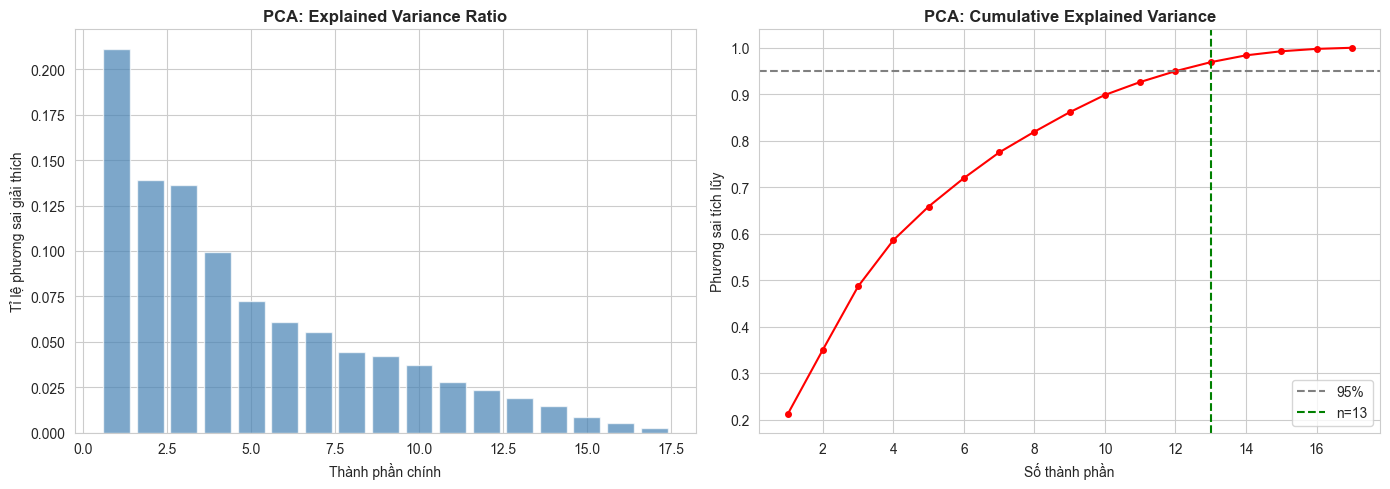

Cần 13 thành phần để giải thích 95% phương sai.


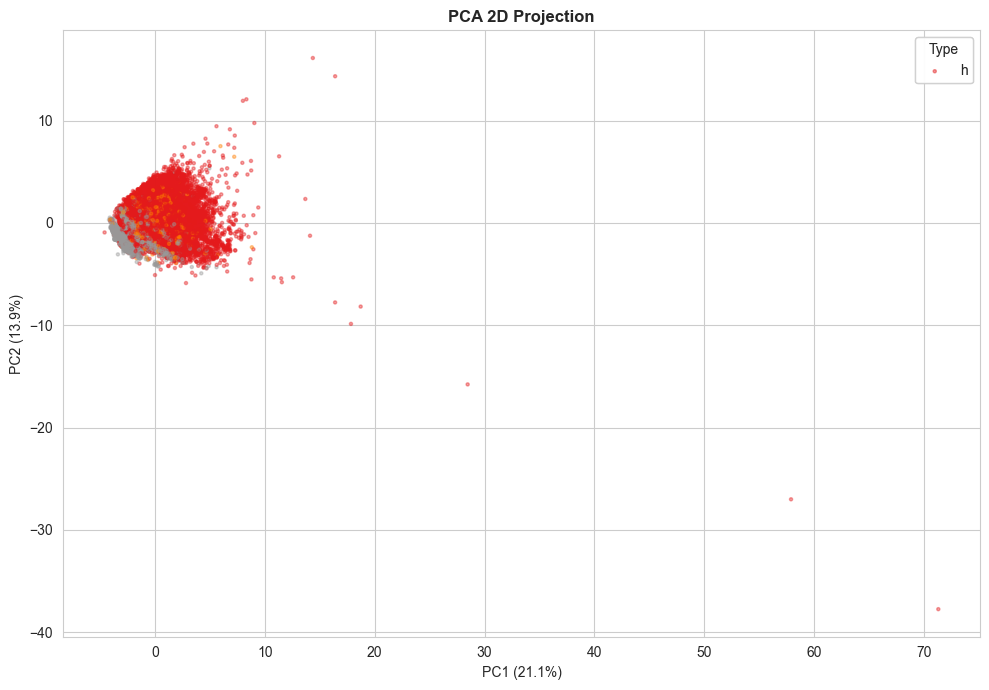

In [24]:
# === PCA ===
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_fs_scaled)

# Explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Thành phần chính')
axes[0].set_ylabel('Tỉ lệ phương sai giải thích')
axes[0].set_title('PCA: Explained Variance Ratio', fontweight='bold')

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'ro-', markersize=4)
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95%')
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[1].axvline(x=n_95, color='green', linestyle='--', label=f'n={n_95}')
axes[1].set_xlabel('Số thành phần')
axes[1].set_ylabel('Phương sai tích lũy')
axes[1].set_title('PCA: Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Cần {n_95} thành phần để giải thích 95% phương sai.')

# PCA 2D visualization
X_pca_2d = X_pca_full[:, :2]
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=y_fs, cmap='Set1', alpha=0.4, s=5)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA 2D Projection', fontweight='bold')
legend1 = ax.legend(*scatter.legend_elements(),
                     title='Type', labels=le_fs.classes_)
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

### E.7 – Giảm chiều – t-SNE & UMAP Visualization

In [25]:
# === t-SNE (dùng subsample do dataset lớn) ===
SAMPLE_SIZE = min(5000, len(X_fs_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(X_fs_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_fs_scaled.iloc[sample_idx]
y_sample = y_fs[sample_idx]

print(f'Chạy t-SNE trên {SAMPLE_SIZE} mẫu...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE
sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=y_sample, cmap='Set1', alpha=0.5, s=8)
axes[0].set_title('t-SNE 2D Projection', fontweight='bold', fontsize=13)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
leg1 = axes[0].legend(*sc1.legend_elements(),
                       title='Type', labels=le_fs.classes_)

# === UMAP ===
try:
    import umap
    print('Chạy UMAP...')
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
    X_umap = reducer.fit_transform(X_sample)
    sc2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1],
                          c=y_sample, cmap='Set1', alpha=0.5, s=8)
    axes[1].set_title('UMAP 2D Projection', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    leg2 = axes[1].legend(*sc2.legend_elements(),
                           title='Type', labels=le_fs.classes_)
except ImportError:
    print('⚠ UMAP không được cài đặt. Cài bằng: pip install umap-learn')
    axes[1].text(0.5, 0.5, 'UMAP not installed\npip install umap-learn',
                 ha='center', va='center', fontsize=14,
                 transform=axes[1].transAxes)
    axes[1].set_title('UMAP (không khả dụng)', fontweight='bold')

plt.tight_layout()
plt.show()

Chạy t-SNE trên 5000 mẫu...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

### E.8 – Phân tích kết quả lựa chọn và giảm chiều đặc trưng

**Nhận xét Tầng 1 – Lọc thống kê:**
- **ANOVA F-test**: Đánh giá khả năng phân biệt các lớp của từng biến số. F-score cao = biến có phân phối khác nhau rõ rệt giữa các lớp.
- **Chi-square test**: Phù hợp cho biến rời rạc/phân loại. Cần dữ liệu non-negative.
- **Mutual Information**: Bắt được cả mối quan hệ phi tuyến, tổng quát hơn ANOVA và Chi-square.

**Nhận xét Tầng 2 – Lọc mô hình:**
- **RF/GB Importance**: Đánh giá đóng góp thực tế trong mô hình. GB thường tập trung vào ít biến quan trọng hơn.
- **RFECV**: Tự động tìm số đặc trưng tối ưu qua cross-validation, tránh chọn thừa hoặc thiếu.

**Nhận xét Tầng 3 – Giảm chiều:**
- **PCA**: Giữ lại phương sai tối đa, phù hợp cho mô hình tuyến tính. Biểu đồ cumulative variance giúp chọn số chiều.
- **t-SNE**: Tốt cho trực quan hóa cấu trúc cục bộ (local structure), nhưng không dùng cho training.
- **UMAP**: Nhanh hơn t-SNE, giữ được cấu trúc toàn cục (global structure) tốt hơn, phù hợp cho dữ liệu lớn.

---
# PHẦN F – Phát hiện và xử lý mất cân bằng lớp

## Lý thuyết

### Tại sao không được áp dụng resampling trước khi chia train/test?
- Nếu resampling (SMOTE, ADASYN, Under-sampling) được áp dụng **trước** khi chia, các mẫu tổng hợp (synthetic samples) có thể **rò rỉ thông tin** từ tập test vào tập train.
- SMOTE tạo mẫu mới bằng cách nội suy giữa các mẫu gốc → nếu một mẫu gốc nằm trong test set, mẫu tổng hợp trong train set sẽ chứa thông tin của test → **data leakage**.
- Kết quả đánh giá sẽ **lạc quan giả** (overly optimistic), gây sai lầm nghiêm trọng.
- **Quy tắc vàng**: Chỉ resampling trên **tập train** sau khi đã chia train/test.

### Các chiến lược
| Phương pháp | Mô tả |
|------------|-------|
| **SMOTE** | Tạo mẫu tổng hợp bằng nội suy giữa mẫu thiểu số và k láng giềng |
| **ADASYN** | Tương tự SMOTE nhưng tạo nhiều mẫu hơn ở vùng khó phân loại |
| **Random Under-sampling** | Giảm mẫu lớp đa số ngẫu nhiên về bằng lớp thiểu số |

### F.1 – Kiểm tra mức độ mất cân bằng

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier as RF_f

# Kiểm tra phân phối lớp
class_counts = pd.Series(y_fs).value_counts().sort_index()
class_labels = le_fs.classes_

print('PHÂN PHỐI LỚP:')
for idx, label in enumerate(class_labels):
    cnt = class_counts[idx]
    pct = cnt / len(y_fs) * 100
    print(f'  {label}: {cnt:6d} ({pct:.1f}%)')

# Imbalance Ratio
ir = class_counts.max() / class_counts.min()
print(f'\nImbalance Ratio (max/min): {ir:.2f}')
if ir > 1.5:
    print('→ Tập dữ liệu CÓ mất cân bằng lớp. Tiến hành resampling.')
    HAS_IMBALANCE = True
else:
    print('→ Tập dữ liệu KHÔNG bị mất cân bằng nghiêm trọng.')
    HAS_IMBALANCE = False

# Biểu đồ phân phối lớp
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(class_labels, class_counts.values, color=colors[:len(class_labels)],
              edgecolor='black', alpha=0.8)
for bar, cnt in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{cnt}', ha='center', fontweight='bold')
ax.set_xlabel('Lớp (Type)')
ax.set_ylabel('Số lượng')
ax.set_title('Phân phối lớp – Kiểm tra mất cân bằng', fontweight='bold')
plt.tight_layout()
plt.show()

### F.2 – Chia Train/Test và áp dụng Resampling

In [ ]:
# Chia train/test TRƯỚC khi resampling
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fs_scaled, y_fs, test_size=0.2, random_state=42, stratify=y_fs
)
print(f'Train: {X_train_f.shape}, Test: {X_test_f.shape}')
print(f'Train class dist: {dict(zip(*np.unique(y_train_f, return_counts=True)))}')
print(f'Test class dist:  {dict(zip(*np.unique(y_test_f, return_counts=True)))}')

# Áp dụng các chiến lược resampling CHỈ trên tập train
resampled_data = {'No Resampling': (X_train_f, y_train_f)}

if HAS_IMBALANCE:
    try:
        from imblearn.over_sampling import SMOTE, ADASYN
        from imblearn.under_sampling import RandomUnderSampler
        
        # SMOTE
        smote = SMOTE(random_state=42)
        X_sm, y_sm = smote.fit_resample(X_train_f, y_train_f)
        resampled_data['SMOTE'] = (X_sm, y_sm)
        print(f'\nSMOTE: {X_sm.shape} → {dict(zip(*np.unique(y_sm, return_counts=True)))}')
        
        # ADASYN
        adasyn = ADASYN(random_state=42)
        X_ad, y_ad = adasyn.fit_resample(X_train_f, y_train_f)
        resampled_data['ADASYN'] = (X_ad, y_ad)
        print(f'ADASYN: {X_ad.shape} → {dict(zip(*np.unique(y_ad, return_counts=True)))}')
        
        # Random Under-sampling
        rus = RandomUnderSampler(random_state=42)
        X_ru, y_ru = rus.fit_resample(X_train_f, y_train_f)
        resampled_data['Random Under-sampling'] = (X_ru, y_ru)
        print(f'Under-sampling: {X_ru.shape} → {dict(zip(*np.unique(y_ru, return_counts=True)))}')
    except ImportError:
        print('⚠ imbalanced-learn chưa cài. Cài bằng: pip install imbalanced-learn')
else:
    print('\nKhông cần resampling vì Imbalance Ratio thấp.')
    print('Tuy nhiên, vẫn demo các phương pháp để minh họa:')
    try:
        from imblearn.over_sampling import SMOTE, ADASYN
        from imblearn.under_sampling import RandomUnderSampler
        
        smote = SMOTE(random_state=42)
        X_sm, y_sm = smote.fit_resample(X_train_f, y_train_f)
        resampled_data['SMOTE'] = (X_sm, y_sm)
        
        adasyn = ADASYN(random_state=42)
        X_ad, y_ad = adasyn.fit_resample(X_train_f, y_train_f)
        resampled_data['ADASYN'] = (X_ad, y_ad)
        
        rus = RandomUnderSampler(random_state=42)
        X_ru, y_ru = rus.fit_resample(X_train_f, y_train_f)
        resampled_data['Random Under-sampling'] = (X_ru, y_ru)
        
        for name, (X_r, y_r) in resampled_data.items():
            print(f'  {name}: {X_r.shape} → {dict(zip(*np.unique(y_r, return_counts=True)))}')
    except ImportError:
        print('⚠ imbalanced-learn chưa cài. Cài bằng: pip install imbalanced-learn')

### F.3 – Huấn luyện và đánh giá mô hình trên tập test chưa tái cân bằng

In [ ]:
# Huấn luyện RF trên mỗi tập resampled, đánh giá trên tập test GỐC
eval_results_f = []

for strategy_name, (X_tr, y_tr) in resampled_data.items():
    clf_f = RF_f(n_estimators=100, random_state=42, n_jobs=-1)
    clf_f.fit(X_tr, y_tr)
    y_pred = clf_f.predict(X_test_f)
    y_proba = clf_f.predict_proba(X_test_f)
    
    prec = precision_score(y_test_f, y_pred, average='macro')
    rec = recall_score(y_test_f, y_pred, average='macro')
    f1 = f1_score(y_test_f, y_pred, average='macro')
    
    # AUC-ROC (OvR)
    try:
        auc = roc_auc_score(y_test_f, y_proba, multi_class='ovr', average='macro')
    except:
        auc = np.nan
    
    eval_results_f.append({
        'Strategy': strategy_name,
        'Precision_macro': round(prec, 4),
        'Recall_macro': round(rec, 4),
        'F1_macro': round(f1, 4),
        'AUC_ROC': round(auc, 4) if not np.isnan(auc) else 'N/A'
    })
    
    print(f'\n=== {strategy_name} ===')
    print(classification_report(y_test_f, y_pred,
                                target_names=le_fs.classes_))

eval_df_f = pd.DataFrame(eval_results_f)
print('\n' + '='*70)
print('BẢNG SO SÁNH TỔNG HỢP (đánh giá trên tập test chưa tái cân bằng)')
print('='*70)
display(eval_df_f)

### F.4 – Trực quan so sánh hiệu năng

In [ ]:
# Biểu đồ so sánh metrics
metrics_to_plot = ['Precision_macro', 'Recall_macro', 'F1_macro']
x_pos = np.arange(len(eval_df_f))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics_to_plot):
    values = eval_df_f[metric].astype(float).values
    bars = ax.bar(x_pos + i*width, values, width, label=metric, alpha=0.85)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Chiến lược Resampling')
ax.set_ylabel('Score')
ax.set_title('So sánh Precision / Recall / F1-macro theo chiến lược resampling',
             fontweight='bold', fontsize=13)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(eval_df_f['Strategy'], rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### F.5 – Phân tích kết quả xử lý mất cân bằng lớp

**Nhận xét:**
- **No Resampling**: Baseline – mô hình có thể thiên lệch về lớp đa số.
- **SMOTE**: Tạo mẫu tổng hợp giúp cải thiện Recall cho lớp thiểu số, nhưng có thể giảm nhẹ Precision nếu mẫu tổng hợp gần ranh giới.
- **ADASYN**: Tập trung vào vùng khó phân loại → có thể cải thiện Recall tốt hơn SMOTE ở vùng biên, nhưng dễ bị overfitting nếu có noise.
- **Random Under-sampling**: Giảm kích thước tập train → nhanh hơn nhưng mất thông tin. Precision có thể giảm do ít dữ liệu training.

**Tại sao KHÔNG được resampling trước khi chia train/test:**
1. **Data leakage**: SMOTE/ADASYN nội suy giữa các mẫu gốc. Nếu mẫu gốc nằm ở cả train lẫn test, mẫu tổng hợp sẽ chứa thông tin test → đánh giá quá lạc quan.
2. **Đánh giá không thực tế**: Tập test phải phản ánh phân phối thực tế trong sản xuất, không nên bị biến đổi.
3. **Quy tắc vàng**: `split → resample(train only) → train → evaluate(original test)`

---
# Tổng kết

| Bước | Phương pháp được chọn | Lý do |
|------|----------------------|-------|
| **Xử lý missing** | MICE / k-NN (tốt nhất theo RMSE) | Khai thác mối quan hệ giữa các biến |
| **Phát hiện ngoại lai** | Kết hợp IQR + Isolation Forest | Cân bằng giữa đơn giản và robust |
| **Chuẩn hóa** | Robust Scaling / Quantile | Ít nhạy outlier, phù hợp dữ liệu lệch |
| **Mã hóa** | One-Hot (low-card) + Binary (high-card) + Target (supervised) | Cân bằng giữa thông tin và chiều dữ liệu |
| **Lọc đặc trưng** | RFECV + RF/GB Importance | Tự động chọn số đặc trưng tối ưu |
| **Giảm chiều** | PCA (giữ 95% var) + t-SNE/UMAP (visualization) | Giảm chiều hiệu quả |
| **Mất cân bằng** | SMOTE / ADASYN (nếu cần) | Cải thiện Recall cho lớp thiểu số |